### XGBoost — IEEE-CIS Fraud Detection

In [1]:
import sys
sys.path.append('.')

import os
import mlflow
import dagshub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from Models.preprocessing import load_data, FraudPreprocessor, ColumnSelector


from dotenv import load_dotenv; load_dotenv()
dagshub.init(repo_owner="lchit22", 
             repo_name="ml-assignment-fraud-detection", 
             mlflow=True)

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

Accessing as lchit22

Initialized MLflow to track repo "lchit22/ml-assignment-fraud-detection"

Repository lchit22/ml-assignment-fraud-detection initialized!

<Experiment: artifact_location='mlflow-artifacts:/6238dd5f86534c6591e0ebebce442d23', creation_time=1777830744228, experiment_id='0', last_update_time=1777830744228, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

#### 1. Data Loading

Total transactions: 590,540
Fraud cases: 20,663 (3.50%)
Legitimate cases: 569,877
Total features: 432


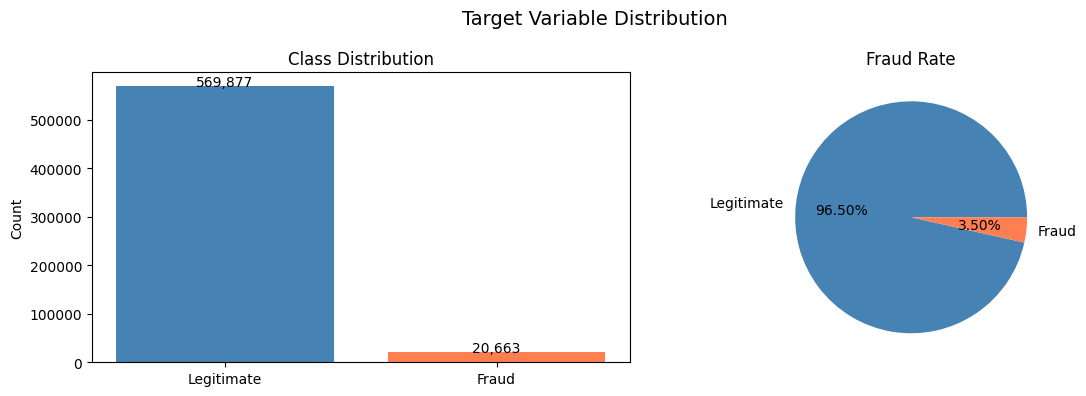


Train: (472432, 432), Val: (118108, 432)


In [9]:
mlflow.set_experiment(EXPERIMENT_NAME)

df = load_data()
X = df.drop(columns=['isFraud', 'TransactionID'])
y = df['isFraud']

print(f"Total transactions: {len(df):,}")
print(f"Fraud cases: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"Legitimate cases: {(y==0).sum():,}")
print(f"Total features: {X.shape[1]}")

# class distribution charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'],
            [y.value_counts()[0], y.value_counts()[1]],
            color=['steelblue', 'coral'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([y.value_counts()[0], y.value_counts()[1]]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center')

axes[1].pie([y.value_counts()[0], y.value_counts()[1]],
            labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'coral'],
            autopct='%1.2f%%')
axes[1].set_title('Fraud Rate')

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('Plots/class_distribution.png')
plt.show()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")

#### 2. Cleaning

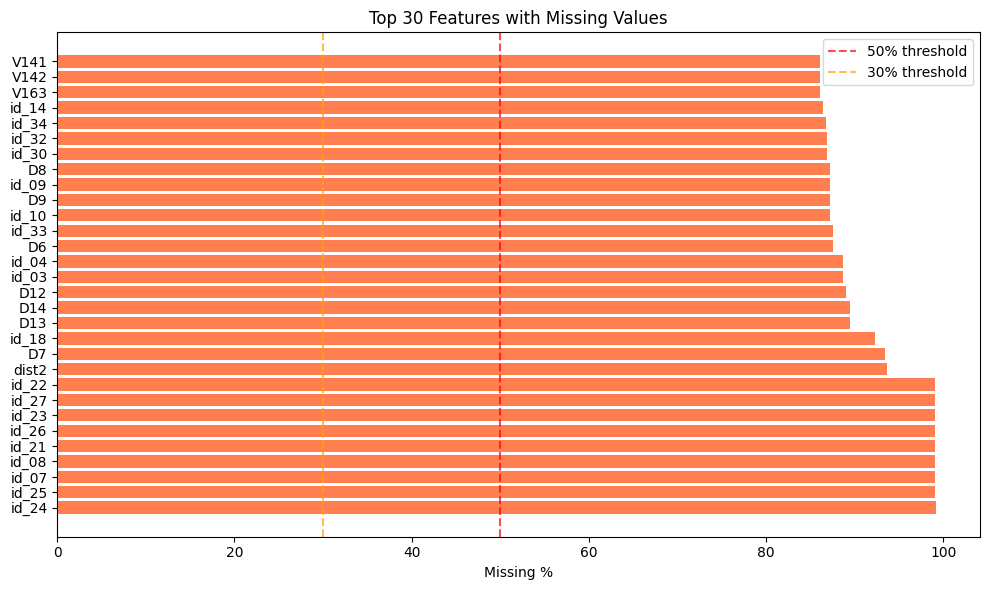

Total features: 432
Approach 1 (>50% missing): drop 214 columns
Approach 2 (>30% missing): drop 232 columns

Chosen: Approach 1 — XGBoost handles missing values natively,
so we only drop extreme cases (>50%)
🏃 View run XGBoost_Cleaning at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/7ef3a0c979244744a359566db7655f6c
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


In [10]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="XGBoost_Cleaning"):

    missing_pct = X_train.isnull().mean().sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]

    fig, ax = plt.subplots(figsize=(10, 6))
    top_missing = missing_pct.head(30)
    colors = ['coral' if x > 0.5 else 'mediumpurple' if x > 0.3 else 'steelblue'
              for x in top_missing]
    ax.barh(top_missing.index, top_missing.values * 100, color=colors)
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
    ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7, label='30% threshold')
    ax.set_xlabel('Missing %')
    ax.set_title('Top 30 Features with Missing Values')
    ax.legend()
    plt.tight_layout()
    plt.savefig('Plots/missing_values.png')
    plt.show()

    drop_50 = missing_pct[missing_pct > 0.5].index.tolist()
    drop_30 = missing_pct[missing_pct > 0.3].index.tolist()

    print(f"Total features: {X_train.shape[1]}")
    print(f"Approach 1 (>50% missing): drop {len(drop_50)} columns")
    print(f"Approach 2 (>30% missing): drop {len(drop_30)} columns")
    print(f"\nChosen: Approach 1 — XGBoost handles missing values natively,")
    print(f"so we only drop extreme cases (>50%)")

    mlflow.log_param("chosen_threshold", 0.5)
    mlflow.log_param("approach1_threshold", 0.5)
    mlflow.log_param("approach2_threshold", 0.3)
    mlflow.log_metric("total_features", X_train.shape[1])
    mlflow.log_metric("approach1_dropped", len(drop_50))
    mlflow.log_metric("approach2_dropped", len(drop_30))
    mlflow.log_metric("missing_cols_total", len(missing_pct))
    mlflow.log_artifact('Plots/missing_values.png')

#### 3. Feature Engineering

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['hour'] = X['TransactionDT'] % 86400 // 3600
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['day_of_week'] = X['TransactionDT'] // 86400 % 7
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:57: PerformanceWarning: Dat

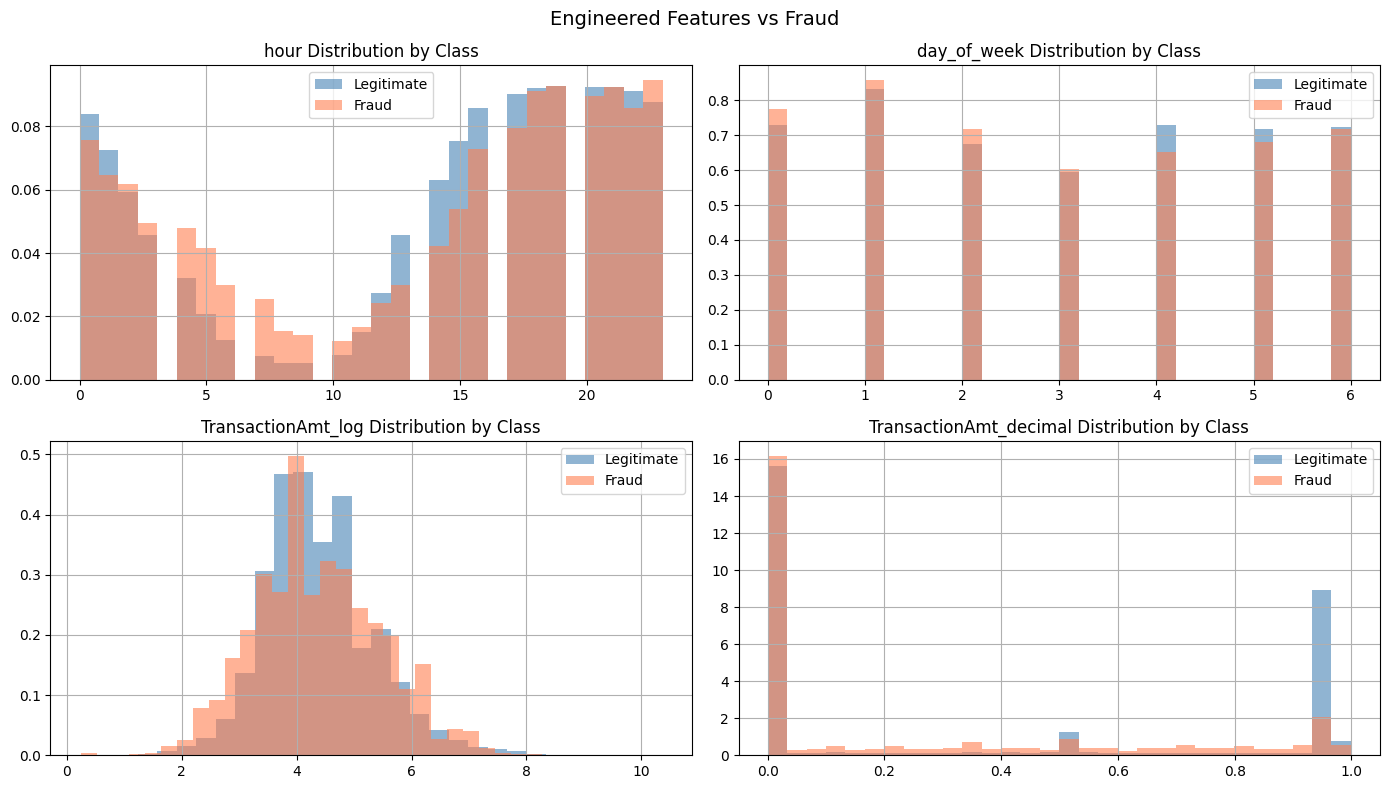

Features before:  432
Features after:   2676

New features added: ['hour', 'day_of_week', 'TransactionAmt_log', 'TransactionAmt_decimal']
Raw TransactionDT and TransactionAmt dropped after engineering
🏃 View run XGBoost_FeatureEngineering at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/a8ff5d4e4d51484ba60b68fee2e32367
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


In [11]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="XGBoost_FeatureEngineering"):

    prep = FraudPreprocessor()
    prep.fit(X_train)
    X_train_transformed = prep.transform(X_train)
    X_val_transformed   = prep.transform(X_val)

    new_features = ['hour', 'day_of_week',
                    'TransactionAmt_log', 'TransactionAmt_decimal']

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    for ax, feat in zip(axes.flatten(), new_features):
        df_plot = pd.DataFrame({
            feat: X_train_transformed[feat],
            'isFraud': y_train.values
        })
        df_plot[df_plot['isFraud'] == 0][feat].hist(
            ax=ax, bins=30, alpha=0.6, color='steelblue',
            label='Legitimate', density=True)
        df_plot[df_plot['isFraud'] == 1][feat].hist(
            ax=ax, bins=30, alpha=0.6, color='coral',
            label='Fraud', density=True)
        ax.set_title(f'{feat} Distribution by Class')
        ax.legend()

    plt.suptitle('Engineered Features vs Fraud', fontsize=14)
    plt.tight_layout()
    plt.savefig('Plots/feature_engineering.png')
    plt.show()

    mlflow.log_param("new_features", str(new_features))
    mlflow.log_param("drop_raw_TransactionDT", True)
    mlflow.log_param("drop_raw_TransactionAmt", True)
    mlflow.log_metric("features_before", X_train.shape[1])
    mlflow.log_metric("features_after_engineering", X_train_transformed.shape[1])
    mlflow.log_artifact('Plots/feature_engineering.png')

    print(f"Features before:  {X_train.shape[1]}")
    print(f"Features after:   {X_train_transformed.shape[1]}")
    print(f"\nNew features added: {new_features}")
    print(f"Raw TransactionDT and TransactionAmt dropped after engineering")

#### 4. Feature Selection

C:\Users\Likun\AppData\Local\Temp\ipykernel_32632\3736351403.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_iv.groupby('col')['target'].agg(['sum', 'count'])
C:\Users\Likun\AppData\Local\Temp\ipykernel_32632\3736351403.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_iv.groupby('col')['target'].agg(['sum', 'count'])
C:\Users\Likun\AppData\Local\Temp\ipykernel_32632\3736351403.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

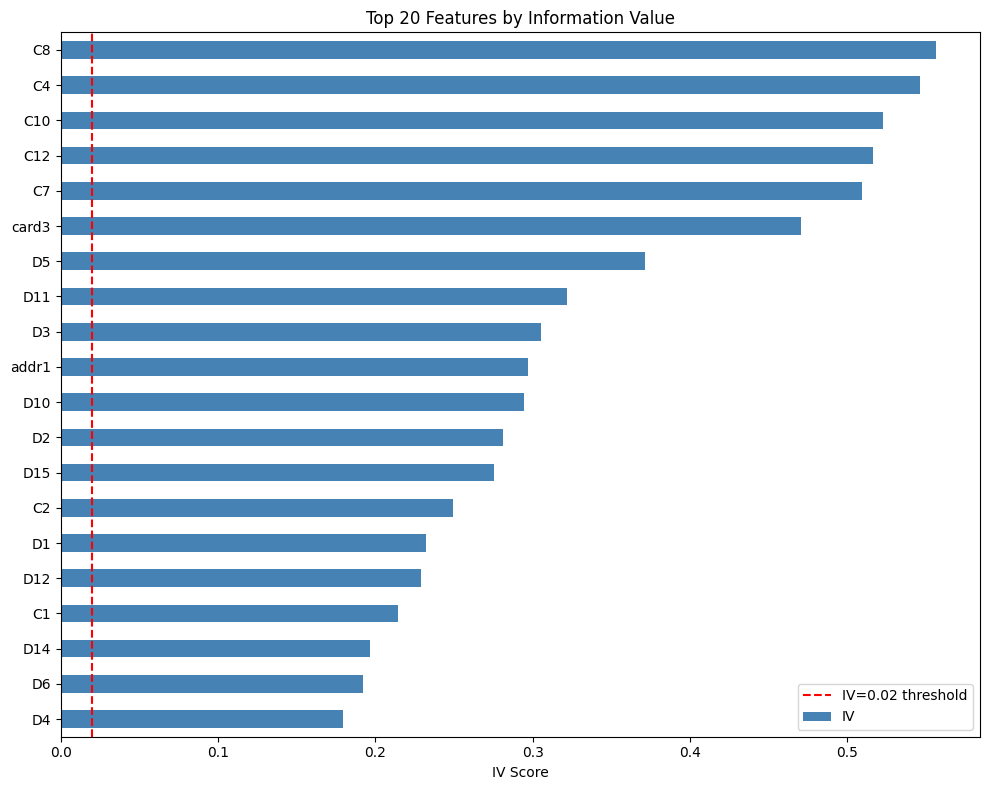

C:\Users\Likun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Likun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

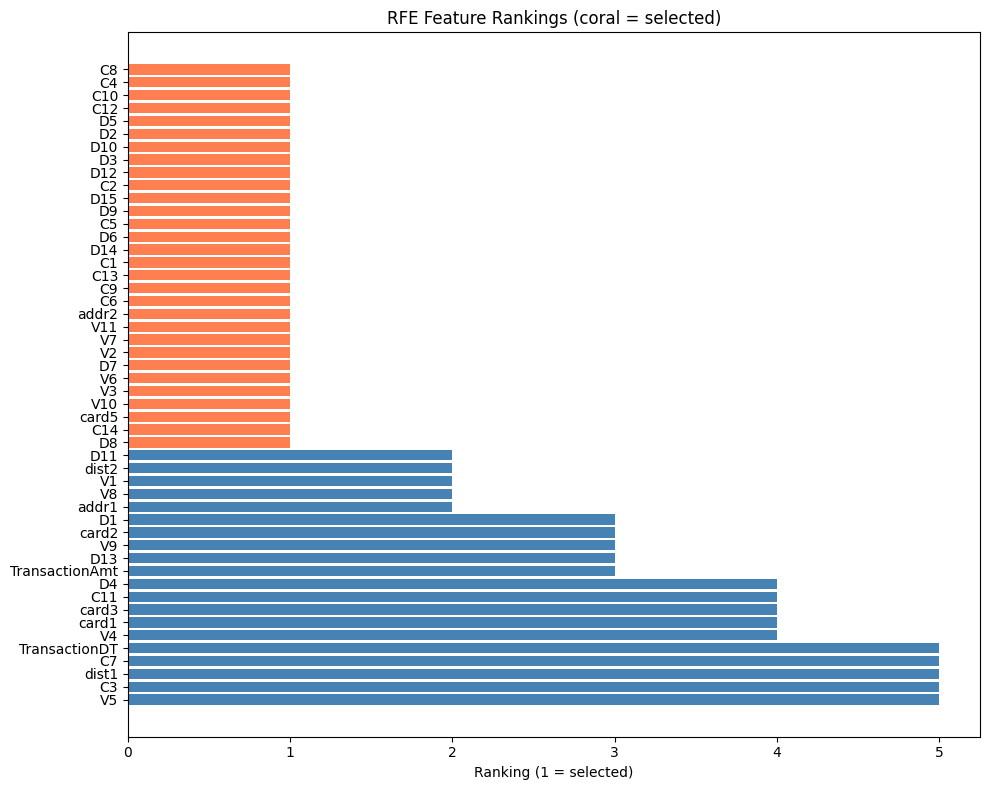

Approach 1 — IV (>0.02):              34 features
Approach 2 — RFE (LogisticRegression): 30 features

Chosen: IV selection (34 features)
🏃 View run XGBoost_FeatureSelection at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/f573f789dd7746fdb1b311c214ce346d
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


In [12]:
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name="XGBoost_FeatureSelection"):

    def calculate_iv(X, y, col):
        df_iv = pd.DataFrame({'col': X[col], 'target': y.values})
        df_iv['col'] = pd.qcut(df_iv['col'], q=10, duplicates='drop')
        grouped = df_iv.groupby('col')['target'].agg(['sum', 'count'])
        grouped['non_event']      = grouped['count'] - grouped['sum']
        grouped['event_rate']     = grouped['sum'] / grouped['sum'].sum()
        grouped['non_event_rate'] = grouped['non_event'] / grouped['non_event'].sum()
        grouped['event_rate']     = grouped['event_rate'].replace(0, 0.0001)
        grouped['non_event_rate'] = grouped['non_event_rate'].replace(0, 0.0001)
        grouped['woe'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
        grouped['iv']  = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
        return grouped['iv'].sum()

    num_cols = X_train_transformed.select_dtypes(include=np.number).columns.tolist()

    iv_scores = {}
    for col in num_cols[:50]:
        try:
            iv_scores[col] = calculate_iv(X_train_transformed, y_train, col)
        except:
            iv_scores[col] = 0

    iv_df = pd.DataFrame.from_dict(iv_scores, orient='index', columns=['IV'])
    iv_df = iv_df.sort_values('IV', ascending=False)
    iv_selected = iv_df[iv_df['IV'] > 0.02].index.tolist()

    # IV chart
    fig, ax = plt.subplots(figsize=(10, 8))
    iv_df.head(20).plot(kind='barh', ax=ax, color='steelblue', legend=False)
    ax.axvline(x=0.02, color='red', linestyle='--', label='IV=0.02 threshold')
    ax.set_title('Top 20 Features by Information Value')
    ax.set_xlabel('IV Score')
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/iv_scores.png')
    plt.show()

    top50_iv = iv_df.head(50).index.tolist()
    top50_iv = [c for c in top50_iv if c in X_train_transformed.columns]

    rfe = RFE(
        estimator=LogisticRegression(max_iter=100, random_state=42),
        n_features_to_select=30,
        step=5
    )
    rfe.fit(X_train_transformed[top50_iv], y_train)
    rfe_selected = [top50_iv[i] for i, s in enumerate(rfe.support_) if s]

    # RFE ranking chart
    rfe_df = pd.DataFrame({
        'feature': top50_iv,
        'ranking': rfe.ranking_
    }).sort_values('ranking')

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['coral' if r == 1 else 'steelblue' for r in rfe_df['ranking']]
    ax.barh(rfe_df['feature'], rfe_df['ranking'], color=colors)
    ax.set_title('RFE Feature Rankings (coral = selected)')
    ax.set_xlabel('Ranking (1 = selected)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('plots/rfe_rankings.png')
    plt.show()

    #  Decision 
    selected_features = iv_selected if len(iv_selected) > 10 else top50_iv

    print(f"Approach 1 — IV (>0.02):              {len(iv_selected)} features")
    print(f"Approach 2 — RFE (LogisticRegression): {len(rfe_selected)} features")
    print(f"\nChosen: IV selection ({len(selected_features)} features)")

    mlflow.log_param("approach1", "Information Value > 0.02")
    mlflow.log_param("approach2", "RFE with LogisticRegression top 30")
    mlflow.log_param("chosen_approach", "IV" if len(iv_selected) > 10 else "top50_IV")
    mlflow.log_param("selected_features", str(selected_features))
    mlflow.log_metric("iv_selected_count", len(iv_selected))
    mlflow.log_metric("rfe_selected_count", len(rfe_selected))
    mlflow.log_metric("final_selected_count", len(selected_features))
    mlflow.log_artifact('plots/iv_scores.png')
    mlflow.log_artifact('plots/rfe_rankings.png')

#### 5. Training & Hyperparameter Tuning

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

underfit_1 | train=0.6806  val=0.6796  gap=0.0010  [underfit]
🏃 View run XGBoost_underfit_1 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/a917a2ff53664b228c25c1dc771d7ea6
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

underfit_2 | train=0.7088  val=0.7093  gap=-0.0005  [underfit]
🏃 View run XGBoost_underfit_2 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/61518825344e4ab0b808cbb943c53f82
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

...

overfit_10 | train=0.9987  val=0.9545  gap=0.0443  [good]
🏃 View run XGBoost_overfit_10 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/888736ebf9184820ae612d628d40e388
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

overfit_11 | train=0.9988  val=0.9540  gap=0.0448  [good]
🏃 View run XGBoost_overfit_11 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/5f57caf643bd4ef5881445a8f6bb0713
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

overfit_12 | train=0.9984  val=0.9545  gap=0.0438  [good]
🏃 View run XGBoost_overfit_12 at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/047c5f10e6c4447493365904443a956e
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0
🏃 View run XGBoost_Training at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/8846958bd17c4bae9a1ca678e17961d1
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0

--- Results Summary ---
      label  n_estimators  max_depth  learning_rate  train_auc  val_auc     gap   status
 underfit_1             5          2          0.005     0.6806   0.6796  0.0010 underfit
 underfit_2            10          2          0.010     0.7088   0.7093 -0.0005 underfit
 underfit_3            20          2          0.010     0.7263   0.7284 -0.0021 underfit
 underfit_4            30          3          0.010

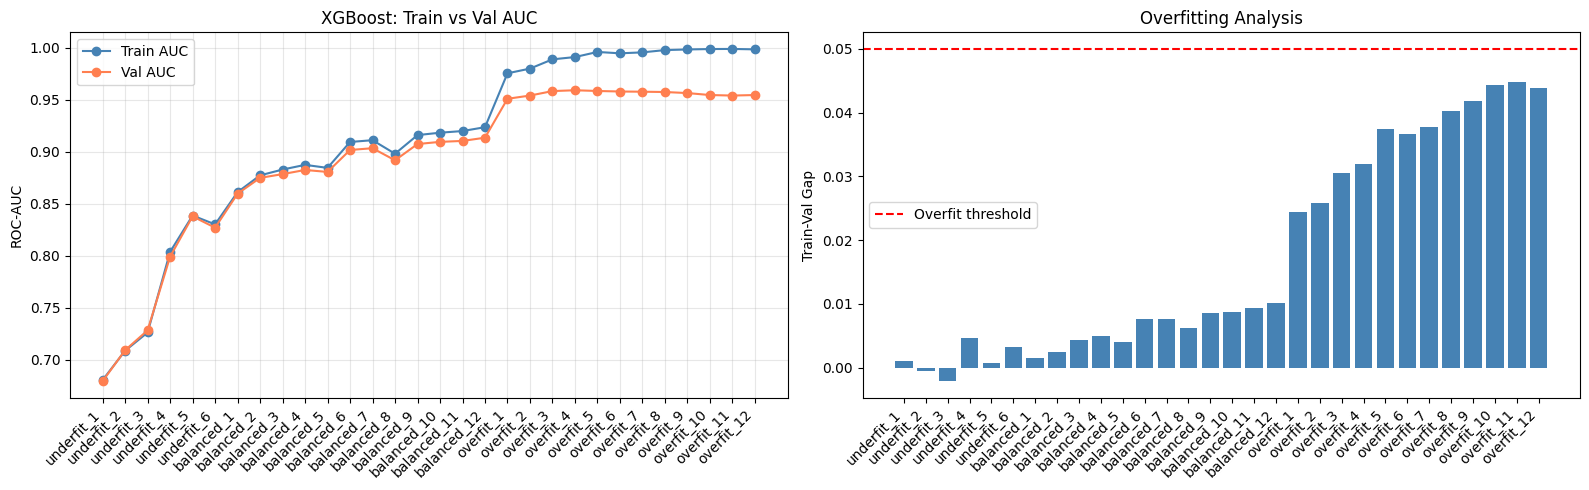

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

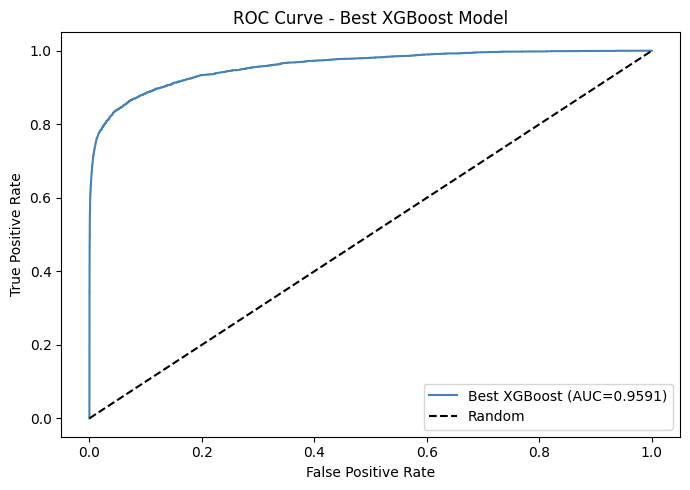


Best val_auc: 0.9591
Best run_id:  bb6cce32ae2944809029cd4b576d624f


In [ ]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selected_features):
        self.selected_features = selected_features

    def fit(self, X, y=None):
        self.features_to_keep_ = [f for f in self.selected_features
                                   if f in X.columns]
        return self

    def transform(self, X, y=None):
        return X[self.features_to_keep_]


mlflow.set_experiment(EXPERIMENT_NAME)

param_grid = [
    # underfit
    {'n_estimators':  5,  'max_depth':  2, 'learning_rate': 0.005, 'label': 'underfit_1'},
    {'n_estimators': 10,  'max_depth':  2, 'learning_rate': 0.01,  'label': 'underfit_2'},
    {'n_estimators': 20,  'max_depth':  2, 'learning_rate': 0.01,  'label': 'underfit_3'},
    {'n_estimators': 30,  'max_depth':  3, 'learning_rate': 0.01,  'label': 'underfit_4'},
    {'n_estimators': 50,  'max_depth':  2, 'learning_rate': 0.05,  'label': 'underfit_5'},
    {'n_estimators': 50,  'max_depth':  3, 'learning_rate': 0.01,  'label': 'underfit_6'},
    # balanced
    {'n_estimators':  80, 'max_depth':  3, 'learning_rate': 0.05,  'label': 'balanced_1'},
    {'n_estimators': 100, 'max_depth':  3, 'learning_rate': 0.1,   'label': 'balanced_2'},
    {'n_estimators': 120, 'max_depth':  4, 'learning_rate': 0.05,  'label': 'balanced_3'},
    {'n_estimators': 150, 'max_depth':  4, 'learning_rate': 0.05,  'label': 'balanced_4'},
    {'n_estimators': 150, 'max_depth':  3, 'learning_rate': 0.1,   'label': 'balanced_5'},
    {'n_estimators': 200, 'max_depth':  4, 'learning_rate': 0.1,   'label': 'balanced_6'},
    {'n_estimators': 200, 'max_depth':  5, 'learning_rate': 0.05,  'label': 'balanced_7'},
    {'n_estimators': 250, 'max_depth':  4, 'learning_rate': 0.05,  'label': 'balanced_8'},
    {'n_estimators': 250, 'max_depth':  5, 'learning_rate': 0.05,  'label': 'balanced_9'},
    {'n_estimators': 300, 'max_depth':  4, 'learning_rate': 0.1,   'label': 'balanced_10'},
    {'n_estimators': 300, 'max_depth':  5, 'learning_rate': 0.05,  'label': 'balanced_11'},
    {'n_estimators': 350, 'max_depth':  5, 'learning_rate': 0.05,  'label': 'balanced_12'},
    # overfit
    {'n_estimators': 300, 'max_depth':  8, 'learning_rate': 0.1,   'label': 'overfit_1'},
    {'n_estimators': 400, 'max_depth':  8, 'learning_rate': 0.1,   'label': 'overfit_2'},
    {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.1,   'label': 'overfit_3'},
    {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1,   'label': 'overfit_4'},
    {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.2,   'label': 'overfit_5'},
    {'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.1,   'label': 'overfit_6'},
    {'n_estimators': 600, 'max_depth': 12, 'learning_rate': 0.1,   'label': 'overfit_7'},
    {'n_estimators': 600, 'max_depth': 15, 'learning_rate': 0.1,   'label': 'overfit_8'},
    {'n_estimators': 700, 'max_depth': 12, 'learning_rate': 0.2,   'label': 'overfit_9'},
    {'n_estimators': 700, 'max_depth': 15, 'learning_rate': 0.2,   'label': 'overfit_10'},
    {'n_estimators': 800, 'max_depth': 15, 'learning_rate': 0.2,   'label': 'overfit_11'},
    {'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.3,   'label': 'overfit_12'},
]

results      = []
best_val_auc = 0
best_pipeline = None
best_run_id   = None

with mlflow.start_run(run_name="XGBoost_Training"):
    for params in param_grid:
        label = params.pop('label')

        with mlflow.start_run(run_name=f"XGBoost_{label}", nested=True):

            pipeline = Pipeline([
                ('preprocessor', FraudPreprocessor()),
                ('selector',     ColumnSelector(selected_features=selected_features)),
                ('model',        xgb.XGBClassifier(
                    **params,
                    random_state=42,
                    eval_metric='auc',
                    n_jobs=-1,
                    verbosity=0
                ))
            ])

            pipeline.fit(X_train, y_train)

            train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
            val_auc   = roc_auc_score(y_val,   pipeline.predict_proba(X_val)[:, 1])
            gap       = train_auc - val_auc

            mlflow.log_params(params)
            mlflow.log_metric("train_auc",      train_auc)
            mlflow.log_metric("val_auc",        val_auc)
            mlflow.log_metric("train_val_gap",  gap)
            mlflow.sklearn.log_model(pipeline, "model")

            status = ('overfit'  if gap > 0.05
                      else 'underfit' if val_auc < 0.85
                      else 'good')

            results.append({
                'label': label, **params,
                'train_auc': round(train_auc, 4),
                'val_auc':   round(val_auc,   4),
                'gap':       round(gap,        4),
                'status':    status
            })
            print(f"{label} | train={train_auc:.4f}  val={val_auc:.4f}  gap={gap:.4f}  [{status}]")

            if val_auc > best_val_auc:
                best_val_auc  = val_auc
                best_pipeline = pipeline
                best_run_id   = mlflow.active_run().info.run_id

        params['label'] = label  # restore

results_df = pd.DataFrame(results)
print("\n--- Results Summary ---")
print(results_df[['label', 'n_estimators', 'max_depth',
                   'learning_rate', 'train_auc', 'val_auc',
                   'gap', 'status']].to_string(index=False))

# Charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(len(results_df))
axes[0].plot(x, results_df['train_auc'], 'o-', color='steelblue', label='Train AUC')
axes[0].plot(x, results_df['val_auc'],   'o-', color='coral',     label='Val AUC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['label'], rotation=45, ha='right')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('XGBoost: Train vs Val AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(results_df['label'], results_df['gap'], color=[
    'coral' if g > 0.05 else 'steelblue' for g in results_df['gap']
])
axes[1].axhline(y=0.05, color='red', linestyle='--', label='Overfit threshold')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(results_df['label'], rotation=45, ha='right')
axes[1].set_ylabel('Train-Val Gap')
axes[1].set_title('Overfitting Analysis')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/xgboost_training.png')
plt.show()

# ROC curve for best model
fpr, tpr, _ = roc_curve(y_val, best_pipeline.predict_proba(X_val)[:, 1])
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'Best XGBoost (AUC={best_val_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best XGBoost Model')
plt.legend()
plt.tight_layout()
plt.savefig('plots/xgboost_roc.png')
plt.show()

print(f"\nBest val_auc: {best_val_auc:.4f}")
print(f"Best run_id:  {best_run_id}")

#### 6. Model registration

In [35]:
import mlflow
from mlflow.models import infer_signature

with mlflow.start_run(run_name="FINAL_MODEL_FIXED_REGISTRY"):

    preds = best_pipeline.predict(X_train.iloc[:10])
    signature = infer_signature(X_train.iloc[:10], preds)

    mlflow.sklearn.log_model(
        best_pipeline,
        name="model",
        signature=signature,
    )

    final_run_id = mlflow.active_run().info.run_id

C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  )
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_cols = [c for c in final_cols if c in X.columns]
C:\Users\Likun\OneDrive\Desktop\Machine Learning\ml-assignment-fraud-detection\Models\preprocessing.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usu

🏃 View run FINAL_MODEL_FIXED_REGISTRY at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0/runs/a09a21b9bc2b4b92890116b0012a546f
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-fraud-detection.mlflow/#/experiments/0


In [2]:
from mlflow import MlflowClient
from mlflow.exceptions import MlflowException
from mlflow.store.artifact.runs_artifact_repo import RunsArtifactRepository

SOURCE_RUN_ID = "bb6cce32ae2944809029cd4b576d624f"
ARTIFACT_SUBPATH = "model"

run_id = SOURCE_RUN_ID
runs_uri = f"runs:/{run_id}/{ARTIFACT_SUBPATH}"
source = RunsArtifactRepository.get_underlying_uri(runs_uri)

client = MlflowClient()
try:
    client.create_registered_model("XGBoost_FraudDetection_Best")
except MlflowException as e:
    if e.error_code not in ("RESOURCE_ALREADY_EXISTS", "ALREADY_EXISTS"):
        raise

result = client.create_model_version(
    name="XGBoost_FraudDetection_Best",
    source=source,
    run_id=run_id,
)
print("Registered version:", result.version)

2026/05/05 20:55:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_FraudDetection_Best, version 2


Registered version: 2
